<a href="https://colab.research.google.com/github/rithika-66/X_RAY_BASED_BONE_FRACTURE_DETECTION/blob/main/elbow_efficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name:
    print('GPU found:', device_name)
else:
    print("No GPU found, using CPU.")

GPU found: /device:GPU:0


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"
test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"  # One-hot encoding for 2 classes
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 4016 files belonging to 2 classes.
Found 465 files belonging to 2 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['negative', 'positive']


In [ ]:
# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
for layer in base_model.layers:
    layer.trainable = False  # freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
preds = Dense(len(class_names), activation="softmax",
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

model = tf.keras.Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
EPOCHS = 10
start_time = time.time()

In [ ]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 763s 6s/step - accuracy: 0.5259 - loss: 0.7414 - val_accuracy: 0.6624 - val_loss: 0.6394
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 198ms/step - accuracy: 0.5685 - loss: 0.6926 - val_accuracy: 0.7011 - val_loss: 0.6031
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 210ms/step - accuracy: 0.6289 - loss: 0.6545 - val_accuracy: 0.7247 - val_loss: 0.5784
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 39s 197ms/step - accuracy: 0.6279 - loss: 0.6429 - val_accuracy: 0.7376 - val_loss: 0.5629
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.6516 - loss: 0.6267 - val_accuracy: 0.7333 - val_loss: 0.5507
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.6731 - loss: 0.6058 - val_accuracy: 0.7376 - val_loss: 0.5413
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - accuracy: 0.6711 - loss: 0.6023 - val_accuracy: 0.7355 - val_loss: 0.5348
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.6790 - loss: 0.5

In [ ]:
end_time = time.time()
training_time = end_time - start_time
print(f"\n Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes).")


 Training completed in 1002.20 seconds (16.70 minutes).


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
]

print("\n[Phase 2] Fine-tuning EfficientNet (last 30 layers)...")
EPOCHS = 30
start_time = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)
end_time = time.time()
training_time = end_time - start_time
print(f"\nFine-tuning completed in {training_time/60:.2f} minutes.")


[Phase 2] Fine-tuning EfficientNet (last 30 layers)...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 78s 391ms/step - accuracy: 0.6059 - loss: 0.6738 - val_accuracy: 0.7419 - val_loss: 0.5172 - learning_rate: 1.0000e-05
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.6849 - loss: 0.5845 - val_accuracy: 0.7355 - val_loss: 0.5147 - learning_rate: 1.0000e-05
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 198ms/step - accuracy: 0.7034 - loss: 0.5651 - val_accuracy: 0.7527 - val_loss: 0.5075 - learning_rate: 1.0000e-05
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step - accuracy: 0.7104 - loss: 0.5536 - val_accuracy: 0.7613 - val_loss: 0.5002 - learning_rate: 1.0000e-05
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.7366 - loss: 0.5467 - val_accuracy: 0.7591 - val_loss: 0.4927 - learning_rate: 1.0000e-05
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.7452 - loss: 0.5271 - val_accuracy: 0.7656 - val_loss: 0.4852 - learning_rate: 1

In [ ]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.8028 - loss: 0.4297
Test Accuracy: 0.8000


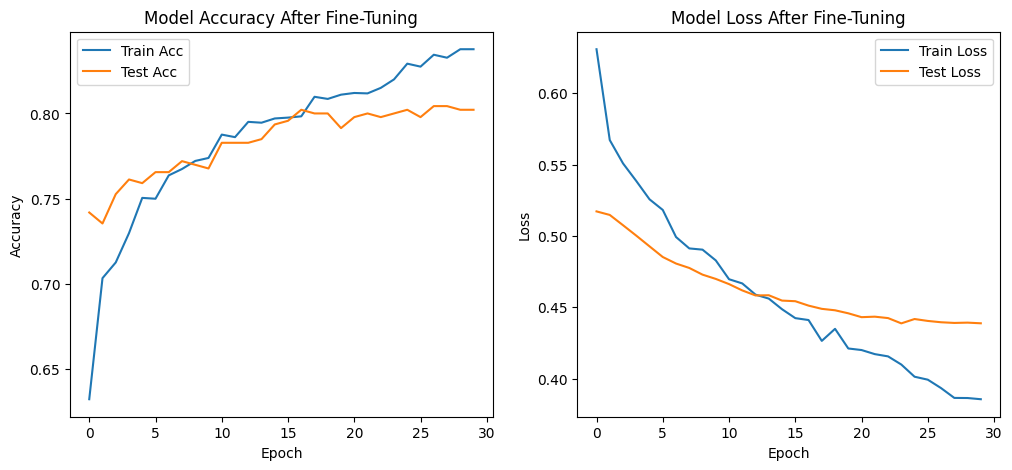

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_finetune.history['accuracy'], label='Train Acc')
plt.plot(history_finetune.history['val_accuracy'], label='Test Acc')
plt.title("Training vs Validation Accuracy ")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1,2,2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Test Loss')
plt.title("Training vs Validation Loss ")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.show()


In [ ]:
# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


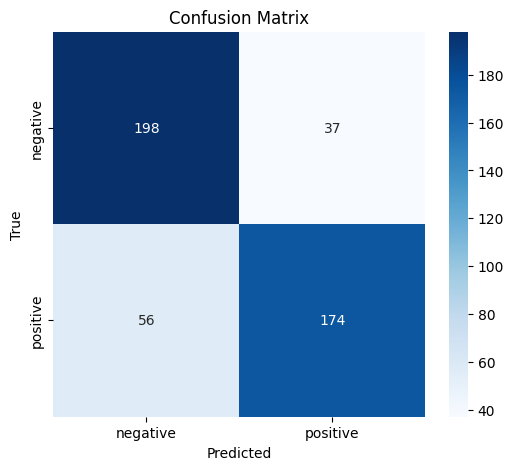

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

    negative       0.78      0.84      0.81       235
    positive       0.82      0.76      0.79       230

    accuracy                           0.80       465
   macro avg       0.80      0.80      0.80       465
weighted avg       0.80      0.80      0.80       465



In [ ]:
# Save in native Keras format
model.save("/content/drive/My Drive/Colab Notebooks/Efficient_Elbow_MURA.keras")
print("Model saved successfully in Keras format!")

Model saved successfully in Keras format!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/"


 4MW22AD055_Sinchana.pdf
'Assignment '
'Certifications (1).csv'
 Certifications.csv
 Certifications.xlsx
 Classroom
'Colab Notebooks'
'Copy of Lab1_Corpus.ipynb'
 data.gsheet
 Lab1_Corpus.ipynb
 Lab5_Text_Classification.ipynb
'Lab6_LSTM_for_Forecasting (1).ipynb'
'ML_Lab_Manual (p1) (1).gdoc'
'ML_Lab_Manual (p1).gdoc'
'panda-reach-step-0-to-step-500 (1).mp4'
'Pragati-Cohort 2.pdf'
'Python for Data Science.pdf'
 QA_BOT
 RoadX_AI_IDEATHON_2025.pdf
'simmilarity-based learning-1.gdoc'
'Sinchana (1).resume.pdf'
'Sinchana (2).resume.pdf'
'Sinchana (3).resume.pdf'
 Sinchana.4MW22AD055.jpg
'Sinchana (4).resume.pdf'
'Sinchana (5).resume.pdf'
'Sinchana_AI-DS_2026 (1).pdf'
 Sinchana_AI-DS_2026.pdf
'Sinchana .jpg'
 SINCHANA.pdf
'SINCHANA_RESUME_-1 (1).pdf'
 SINCHANA-RESUME-1.pdf
 SINCHANA_RESUME_-1.pdf
'Sinchana-Resume (1).pdf'
 Sinchana.resume.pdf
 Sinchana-Resume.pdf
 Sinchana_Resume.pdf
 SINCHANA-RESUME.pdf
'Task1 - QA_BOT.ipynb'
'Task 2 - Optimising RAG.pdf'
'Task 3 - Dataset Preparation for F

In [ ]:

test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:


from tensorflow.keras.preprocessing import image_dataset_from_directory
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 465 files belonging to 2 classes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 465 files belonging to 2 classes.
Loaded dataset into memory: (465, 224, 224, 3) (465, 2)
Last conv layer: top_conv
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


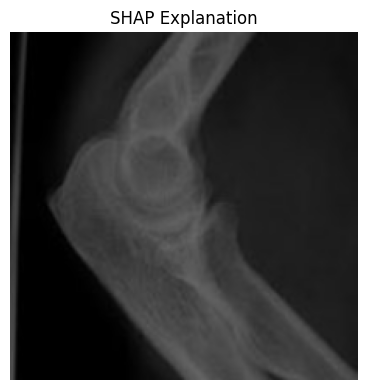

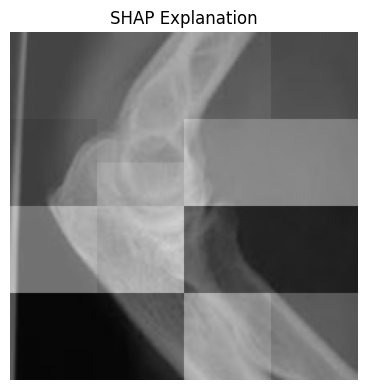

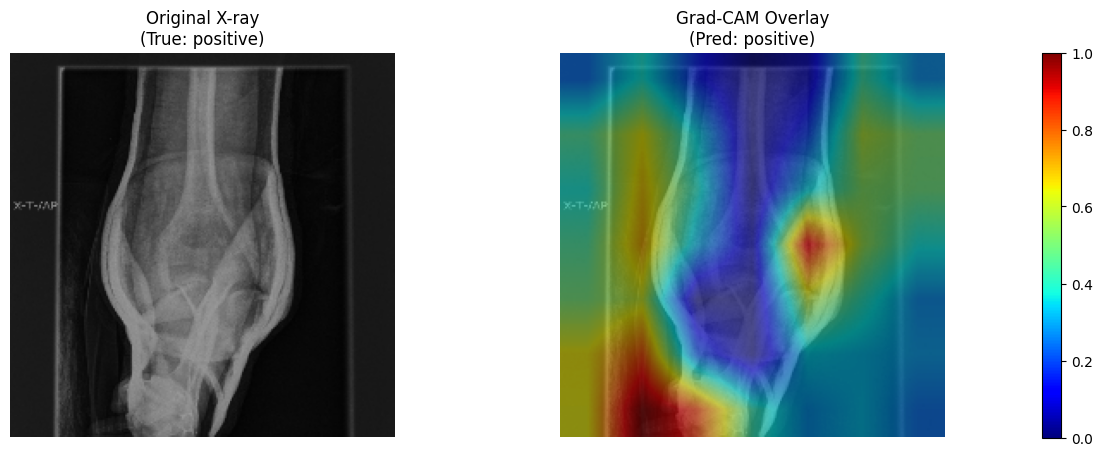

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# --- Dataset setup (your existing settings) ---
test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

from tensorflow.keras.preprocessing import image_dataset_from_directory
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# --- Imports ---
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# --- Load trained model ---
model = load_model("/content/drive/MyDrive/Efficient_Elbow_MURA.keras")

# --- Grad-CAM helpers (unchanged computation) ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# --- overlay_gradcam now supports intensity ---
def overlay_gradcam(img, heatmap, alpha=0.4, intensity=1.5, colormap=cv2.COLORMAP_JET):
    """
    img: HxWxC (uint8 or float)
    heatmap: HxW float in [0,1] (from make_gradcam_heatmap)
    intensity: float >0. Use >1 to increase contrast/saturation of heatmap.
    Returns: overlay_img (RGB uint8), heatmap_for_plot (float [0,1])
    """
    img_uint8 = np.uint8(img)

    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))

    # Boost intensity using power transform; clip -> normalize to [0,1]
    heatmap_boosted = np.power(np.clip(heatmap_resized, 0.0, 1.0), intensity)
    if heatmap_boosted.max() > 0:
        heatmap_boosted = heatmap_boosted / (heatmap_boosted.max() + 1e-8)

    # Convert to uint8 and apply OpenCV colormap (BGR)
    heatmap_uint8 = np.uint8(255 * heatmap_boosted)
    heatmap_colored_bgr = cv2.applyColorMap(heatmap_uint8, colormap)

    # Convert BGR -> RGB for matplotlib
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored_bgr, cv2.COLOR_BGR2RGB)

    # Blend overlay
    superimposed_img = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored_rgb, alpha, 0)

    return superimposed_img, heatmap_boosted

# --- Convert dataset to NumPy arrays (Option A) ---
X_batches = []
Y_batches = []
for images, labels in test_ds:
    X_batches.append(images.numpy())
    Y_batches.append(labels.numpy())

X_all = np.concatenate(X_batches, axis=0)
Y_all = np.concatenate(Y_batches, axis=0)
print("Loaded dataset into memory:", X_all.shape, Y_all.shape)

# --- Class names and last conv layer detection ---
class_names = test_ds.class_names
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
if last_conv_layer_name is None:
    raise RuntimeError("No Conv2D layer found in the model.")
print("Last conv layer:", last_conv_layer_name)

# --- explain_gradcam now takes intensity ---
def explain_gradcam(index, show_plot=True, alpha=0.4, intensity=1.5):
    """
    index: int or list of ints (0-based)
    alpha: blend factor (0..1)
    intensity: heatmap power (>1 increases contrast)
    """
    if isinstance(index, (list, tuple, np.ndarray)):
        return [explain_gradcam(int(i), show_plot=show_plot, alpha=alpha, intensity=intensity) for i in index]

    if index < 0 or index >= len(X_all):
        raise IndexError(f"Index out of range (0..{len(X_all)-1})")

    X_orig = np.expand_dims(X_all[index].astype('uint8'), axis=0)
    y_true = np.expand_dims(Y_all[index], axis=0)
    X_pre = preprocess_input(X_orig.copy())

    preds = model.predict(X_pre)
    pred_label = class_names[np.argmax(preds)]
    if y_true.shape[-1] == len(class_names):
        true_label = class_names[np.argmax(y_true)]
    else:
        true_label = class_names[int(y_true)]

    heatmap = make_gradcam_heatmap(X_pre, model, last_conv_layer_name)
    overlay_img, heatmap_for_plot = overlay_gradcam(X_orig[0], heatmap, alpha=alpha, intensity=intensity)

    # Plot: Original | Overlay | Heatmap (+ colorbar)
    import matplotlib as mpl
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.12], wspace=0.08)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(X_orig[0].astype('uint8'))
    ax0.set_title(f"Original X-ray\n(True: {true_label})")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(overlay_img)
    ax1.set_title(f"Grad-CAM Overlay\n(Pred: {pred_label})")
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[0, 2])
    im = ax2.imshow(heatmap_for_plot, cmap='jet', vmin=0.0, vmax=1.0)

    ax2.axis("off")

    cbar = fig.colorbar(im, ax=ax2, fraction=1.0, pad=0.01)


    if show_plot:
        plt.show()

    return {
        "index": index,
        "X_orig": X_orig,
        "X_pre": X_pre,
        "y_true": y_true,
        "preds": preds,
        "heatmap": heatmap,
        "heatmap_for_plot": heatmap_for_plot,
        "overlay_img": overlay_img,
    }

# --- Example usage: tune intensity & alpha ---
result = explain_gradcam(245, alpha=0.5, intensity=1.0)


In [ ]:
!pip install gradio shap opencv-python tensorflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ===============================
# IMPORTS
# ===============================
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
import shap
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import drive

# ===============================
# MOUNT GOOGLE DRIVE
# ===============================
drive.mount('/content/drive')

# ===============================
# CONFIG
# ===============================
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/Efficient_Elbow_MURA.keras"
IMG_SIZE = (224, 224)
CLASS_NAMES = ["Normal", "Fractured"]

# ===============================
# LOAD MODEL
# ===============================
model = load_model(MODEL_PATH)

# ===============================
# FIND LAST CONV LAYER (FOR GRAD-CAM)
# ===============================
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("✅ Last Conv Layer:", last_conv_layer_name)

# ===============================
# GRAD-CAM FUNCTIONS
# ===============================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

# ===============================
# SHAP EXPLANATION (STABLE VERSION)
# ===============================
def shap_explain(img):
    img_r = cv2.resize(img, IMG_SIZE)
    X = np.expand_dims(img_r.astype("uint8"), axis=0)

    def f(x):
        return model(preprocess_input(x.copy()))

    masker = shap.maskers.Image("inpaint_telea", X[0].shape)
    explainer = shap.Explainer(f, masker)

    shap_values = explainer(X, max_evals=50, batch_size=1)

    # Aggregate SHAP values
    s = shap_values.values[0].sum(axis=-1)
    s -= s.min()
    if s.max() != 0:
        s /= s.max()

    # Plot SHAP overlay
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    ax.imshow(s, cmap="jet", alpha=0.45)
    ax.set_title("SHAP Explanation")
    ax.axis("off")
    plt.tight_layout()

    return fig

# ===============================
# PREDICTION FUNCTION
# ===============================
def predict(img):
    img_r = cv2.resize(img, IMG_SIZE)
    X = preprocess_input(np.expand_dims(img_r, axis=0))

    preds = model.predict(X)[0]
    label = CLASS_NAMES[np.argmax(preds)]

    # Grad-CAM
    heatmap = make_gradcam_heatmap(X, model, last_conv_layer_name)
    gradcam_img = overlay_gradcam(img_r, heatmap)

    # SHAP
    shap_fig = shap_explain(img_r)

    return label, gradcam_img, shap_fig

# ===============================
# GRADIO INTERFACE
# ===============================
gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy", label="Upload Elbow X-ray"),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Image(label="Grad-CAM Explanation"),
        gr.Plot(label="SHAP Explanation")
    ],
    title="Elbow Fracture Detection with Explainable AI",
    description=(
        "EfficientNet-based elbow fracture detection system with "
        "Grad-CAM and SHAP explanations for clinical interpretability."
    )
).launch(share=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Last Conv Layer: top_conv
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd009713b22cfd0ea4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
